---
title: "Wykład 5: Mechanika NumPy — indeksowanie, osie, broadcasting"
format:
  html:
    embed-resources: true
    self-contained: true
---

## 5.1 Od intuicji do mechaniki

Na poprzednim wykładzie pracowaliśmy z 5-wymiarowym datasetem mikroskopowym i odkryliśmy, że NumPy radzi sobie z takimi danymi naturalnie. Pisaliśmy `data[25, 2, 0, :, :]` żeby wyciągnąć jedną klatkę, `time_series.mean(axis=0)` żeby uśrednić po czasie, `frame[frame > 3000]` żeby wybrać jasne piksele. Wyniki były sensowne — ale *dlaczego* te operacje działają tak, jak działają?

Aby to wyjaśnić, zaczniemy od małych, syntetycznych tablic, na których mechanika NumPy jest widoczna „gołym okiem". Potem wrócimy do obrazu mitozy. Nowe techniki pozwolą nam zobaczyć w tych danych rzeczy, których wcześniej nie mogliśmy: kolorowy obraz łączący oba kanały, automatyczną detekcję momentu rozdzielenia chromatyd, czy korekcję artefaktów mikroskopowych.

Zacznijmy od importu i wczytania znanych danych:


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tf

with tf.TiffFile("data/mitosis.tif") as tif:
    data = tif.asarray()  # Shape: (51, 5, 2, 196, 171)
    axes_str = tif.series[0].axes  # 'TZCYX'

print(f"Shape: {data.shape}, Axes: {axes_str}")

Shape: (51, 5, 2, 196, 171), Axes: TZCYX


## 5.2 Anatomia array — shape, osie, wymiary

### 5.2.1 Co to jest oś?

Rozważmy prostą tablicę 2D — wyniki czterech studentów z trzech egzaminów:


In [4]:
grades = np.array(
    [
        [4, 3, 5],  # Anna
        [3, 4, 4],  # Bartek
        [5, 5, 4],  # Celina
        [2, 3, 3],  # Dawid
    ]
)

print(f"Shape: {grades.shape}")  # (4, 3)
print(f"Wymiary (ndim): {grades.ndim}")

Shape: (4, 3)
Wymiary (ndim): 2


Shape `(4, 3)` oznacza: 4 elementy wzdłuż osi 0, 3 elementy wzdłuż osi 1. Ale co *jest* osią? Przydatna intuicja: **oś to kierunek, wzdłuż którego przesuwamy indeks**. W tej tablicy:

* **Oś 0 (wiersze)** — przesuwamy się między studentami: `grades[0]` → Anna, `grades[1]` → Bartek, ...
* **Oś 1 (kolumny)** — przesuwamy się między egzaminami: `grades[:, 0]` → pierwszy egzamin, `grades[:, 1]` → drugi, ...


### 5.2.2 Agregacja po osi — „która oś znika?"

Chcemy obliczyć średnią ocenę każdego studenta. To znaczy: dla każdego wiersza uśrednij po kolumnach (egzaminach):


In [5]:
mean_per_student = grades.mean(axis=1)  # oś 1 (egzaminy) znika

In [6]:
mean_per_student  # średnia per student

array([4.        , 3.66666667, 4.66666667, 2.66666667])

In [7]:
mean_per_student.shape  # (4,) — zostali studenci

(4,)

A średnia z każdego egzaminu? Uśredniamy po studentach (oś 0):


In [8]:
mean_per_exam = grades.mean(axis=0)  # oś 0 (studenci) znika

In [9]:
mean_per_exam  # średnia per egzamin

array([3.5 , 3.75, 4.  ])

In [10]:
mean_per_exam.shape  # (3,) — zostały egzaminy

(3,)

**Reguła:** `aggregation(axis=N)` eliminuje wymiar N z kształtu tablicy. Jeśli miałeś `(4, 3)` i zrobisz `mean(axis=0)`, wymiar 4 znika, zostaje `(3,)`. Zrobisz `mean(axis=1)` — znika 3, zostaje `(4,)`.


### 5.2.3 Przejście do 3D

Dodajmy wymiar: dwa semestry, czterech studentów, trzy egzaminy.


In [11]:
# Shape: (2, 4, 3) = (semestry, studenci, egzaminy)
all_grades = np.array(
    [
        [
            [4, 3, 5],
            [3, 4, 4],
            [5, 5, 4],
            [2, 3, 3],
        ],  # semestr 0
        [
            [3, 5, 4],
            [4, 5, 4],
            [5, 5, 5],
            [3, 4, 4],
        ],  # semestr 1
    ]
)
print(f"Shape: {all_grades.shape}")  # (2, 4, 3)

Shape: (2, 4, 3)


Ta sama reguła działa w 3D:


In [12]:
# Średnia po semestrach (oś 0 znika): jak każdy student
# wypadł na każdym egzaminie, uśredniając po semestrach?
all_grades.mean(axis=0).shape  # (4, 3) — studenci × egzaminy

(4, 3)

In [13]:
# Średnia po studentach (oś 1 znika): jaka była średnia klasy
# na każdym egzaminie w każdym semestrze?
all_grades.mean(axis=1).shape  # (2, 3) — semestry × egzaminy

(2, 3)

In [14]:
# Średnia po egzaminach (oś 2 znika): jaka była ogólna średnia
# każdego studenta w każdym semestrze?
all_grades.mean(axis=2).shape  # (2, 4) — semestry × studenci

(2, 4)

Można też agregować po wielu osiach jednocześnie:


In [15]:
# Średnia po studentach i egzaminach — zostaje tylko semestr
print(all_grades.mean(axis=(1, 2)).shape)  # (2,)

(2,)


In [16]:
# Globalna średnia — wszystko znika
print(all_grades.mean())  # skalar

4.0


### 5.2.4 Wracamy do mitozy

Przypomnijmy: `data.shape = (51, 5, 2, 196, 171)`, osie to `TZCYX`. Na wykładzie 4 robiliśmy:

```python
time_series = data[:, 2, 0, :, :]          # (51, 196, 171)
mean_image  = time_series.mean(axis=0)      # (196, 171)
intensity   = time_series.mean(axis=(1, 2)) # (51,)
```

Teraz wiemy precyzyjnie, dlaczego te shape'y wychodzą tak, jak wychodzą. `mean(axis=0)` eliminuje pierwszy wymiar (51 klatek) — zostaje obraz. `mean(axis=(1, 2))` eliminuje Y i X — zostaje wektor po czasie.

Ale jest pytanie, którego w zeszłym tygodniu nie zadaliśmy: **jak rozkłada się intensywność fluorescencji po głębokości Z — i czy oba kanały mają maksimum na tej samej warstwie?**


In [17]:
# Dla momentu t=25: średnia intensywność per Z-slice, per kanał
# data[25, ...] ma shape (5, 2, 196, 171) — Z × C × Y × X
# Symbol ... oznacza "wszystkie pozostałe osie" — w tym przypadku Z × C × Y × X
# Równoważne: data[25, :, :, :, :]
# Agregujemy po Y i X (osie 2 i 3) — zostaje Z × C

z_profile = data[25, ...].mean(axis=(2, 3))  # shape: (5, 2)

In [18]:
z_profile.shape

(5, 2)

In [19]:
z_profile[:, 0].round(0)  # kanał 0 (chromosomy)

array([2126., 2205., 2311., 2215., 2157.])

In [20]:
z_profile[:, 1].round(0)  # kanał 1 (wrzeciono)

array([2539., 2961., 3023., 2987., 2751.])

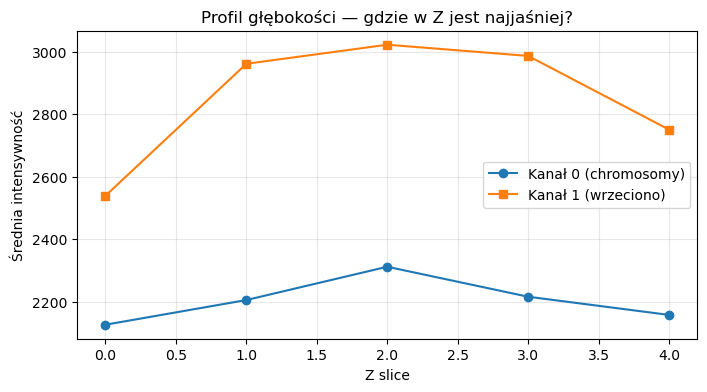

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(z_profile[:, 0], "o-", label="Kanał 0 (chromosomy)")
ax.plot(z_profile[:, 1], "s-", label="Kanał 1 (wrzeciono)")
ax.set_xlabel("Z slice")
ax.set_ylabel("Średnia intensywność")
ax.set_title("Profil głębokości — gdzie w Z jest najjaśniej?")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

Oba kanały mają maximum na Z=2 (środek stacku), co ma sens — mikroskopista ustawia fokus na najciekawszą warstwę. Wrzeciono (kanał 1) jest jaśniejsze od chromosomów (kanał 0) na każdej głębokości — intensywność fluorescencji zależy od ilości barwnika, a mikrotubule wrzeciona zajmują więcej objętości niż skondensowane chromosomy.


## 5.3 Indeksowanie — systematyczny przegląd

Na wykładzie 4 używaliśmy indeksowania intuicyjnie: `data[25, 2, 0, :, :]` żeby wyciągnąć klatkę, `frame[frame > 3000]` żeby wybrać jasne piksele. Teraz zobaczymy, że NumPy oferuje trzy odrębne mechanizmy indeksowania, z których każdy ma inne zachowanie.


### 5.3.1 Basic slicing — wycinki

To najbardziej podstawowa operacja: wybieramy zakres elementów za pomocą składni `start:stop:step`.


In [22]:
arr = np.arange(12).reshape(3, 4)
arr

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [23]:
# Wiersz 0
arr[0, :]

array([0, 1, 2, 3])

In [24]:
# Wiersze 0 i 1
arr[0:2, :]

array([[0, 1, 2, 3],
       [4, 5, 6, 7]])

In [25]:
# Kolumna 2
arr[:, 2]

array([ 2,  6, 10])

In [26]:
# Blok 2×2 z lewego górnego rogu
arr[0:2, 0:2]

array([[0, 1],
       [4, 5]])

Trzeci element składni — **step** — pozwala przeskakiwać co N-ty element:


In [27]:
arr_long = np.arange(10)
arr_long

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [28]:
arr_long[::2]  # 0, 2, 4, 6, 8

array([0, 2, 4, 6, 8])

In [29]:
arr_long[::3]  # 0, 3, 6, 9

array([0, 3, 6, 9])

In [30]:
arr_long[::-1]  # 9, 8, 7, ..., 0

array([9, 8, 7, 6, 5, 4, 3, 2, 1, 0])

**Ważna właściwość:** basic slicing zwraca **widok (view)**, nie kopię danych. Zmiana widoku zmienia oryginał:


In [31]:
original = np.array([10, 20, 30, 40, 50])
view = original[1:4]
view

array([20, 30, 40])

In [32]:
view[0] = 999 # zmieniamy widok

In [33]:
original  # [10, 999, 30, 40, 50] — zmieniony!

array([ 10, 999,  30,  40,  50])

To nie jest błąd — to celowy mechanizm oszczędzający pamięć. Kiedy wycinamy `data[25, 2, 0, :, :]`, NumPy nie kopiuje 196×171 pikseli — wskazuje na istniejący region pamięci. Przy 33 MB datasecie to bez znaczenia, ale przy gigabajtowych danych MRI — krytyczne.


### 5.3.2 Fancy indexing — lista indeksów

Zamiast zakresu `start:stop` możemy podać **konkretną listę pozycji**:


In [34]:
arr = np.array([10, 20, 30, 40, 50, 60, 70])
arr

array([10, 20, 30, 40, 50, 60, 70])

In [35]:
# Wybieramy elementy na pozycjach 0, 3, 6
arr[[0, 3, 6]]  # [10, 40, 70]

array([10, 40, 70])

In [36]:
# Kolejność dowolna, powtórzenia dozwolone
arr[[6, 0, 0, 3]]  # [70, 10, 10, 40]

array([70, 10, 10, 40])

**Kluczowa różnica:** fancy indexing zwraca **kopię**, nie widok. To logiczne — wybrane elementy mogą leżeć w rozrzuconych miejscach pamięci, więc nie da się ich opisać jednym ciągłym zakresem.

Zastosowanie na danych mitozy — montaż wybranych klatek. Zamiast animacji Plotly, chcemy zobaczyć 6 kluczowych momentów obok siebie:


Shape: (6, 196, 171)


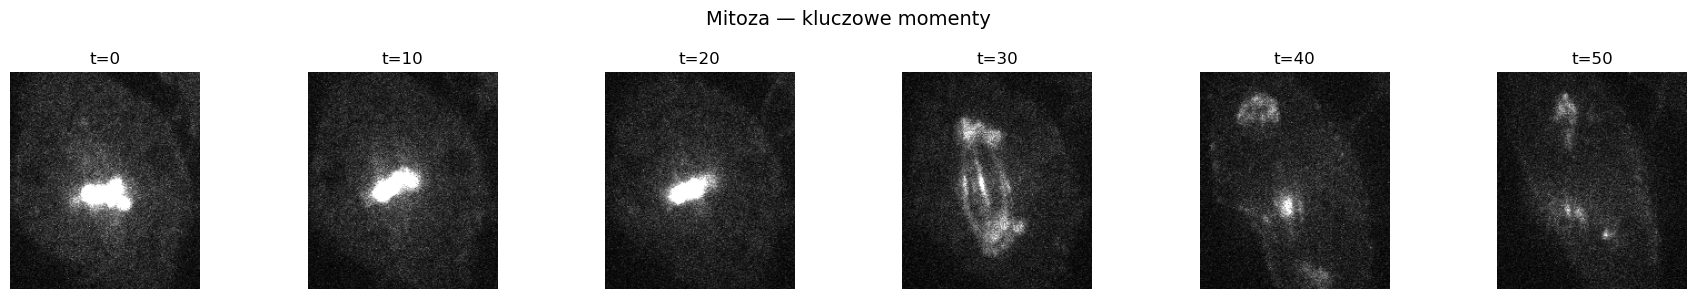

In [37]:
key_frames = [0, 10, 20, 30, 40, 50]
selected = data[key_frames, 2, 0, :, :]  # fancy indexing po osi T
print(f"Shape: {selected.shape}")  # (6, 196, 171)

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for i, t in enumerate(key_frames):
    axes[i].imshow(
        selected[i],
        cmap="gray",
        vmin=data[:, 2, 0].min(),
        vmax=np.percentile(data[:, 2, 0], 99),
    )
    axes[i].set_title(f"t={t}")
    axes[i].axis("off")
plt.suptitle("Mitoza — kluczowe momenty", fontsize=14)
plt.tight_layout()
plt.show()

Na jednym obrazku widzimy całą historię podziału: od jednej grupy chromosomów (t=0) przez rozdzielenie do dwóch grup (t=50). To samo co animacja Plotly z wykładu 4 — ale w formie, którą można włożyć do publikacji.


### 5.3.3 Boolean indexing — maski logiczne

To mechanizm, którego używaliśmy do segmentacji chromosomów. Teraz zobaczymy go systematycznie.


In [38]:
arr = np.array([15, 8, 22, 3, 17, 11])

mask = arr > 10
mask

array([ True, False,  True, False,  True,  True])

In [39]:
mask.dtype

dtype('bool')

In [40]:
arr[mask]

array([15, 22, 17, 11])

In [41]:
arr[mask].shape   # (4,) — NIE oryginalne (6,)

(4,)

**Kluczowy fakt:** boolean indexing *zawsze* zwraca wektor 1D — nawet jeśli oryginalna tablica jest 2D, 3D, czy 5D. NumPy nie ma jak zachować struktury, bo `True` mogą leżeć w dowolnych pozycjach.

In [42]:
arr2d = np.array([[1, 5, 9], [2, 8, 7], [3, 6, 4]])
arr2d

array([[1, 5, 9],
       [2, 8, 7],
       [3, 6, 4]])

In [43]:
arr2d[arr2d > 5]

array([9, 8, 7, 6])

Warunki można łączyć — ale wymagają nawiasów i operatorów `&` (i), `|` (lub), `~` (zaprzeczenie):


In [44]:
arr = np.array([15, 8, 22, 3, 17, 11])
arr

array([15,  8, 22,  3, 17, 11])

In [45]:
# Wartości MIĘDZY 10 a 20
arr[(arr > 10) & (arr < 20)]  # [15, 17, 11]

array([15, 17, 11])

In [46]:
# Wartości PONIŻEJ 5 LUB POWYŻEJ 20
arr[(arr < 5) | (arr > 20)]  # [22, 3]

array([22,  3])

**Czemu nawiasy są konieczne?** W Pythonie `&` ma wyższy priorytet niż `>`. Bez nawiasów `arr > 10 & arr < 20` zostałoby zinterpretowane jako `arr > (10 & arr) < 20`, co daje bezsensowny wynik.


### 5.3.4 `np.where` — zachowanie kształtu

Boolean indexing traci strukturę. Często chcemy czegoś innego: zachować kształt, ale podmienić wartości. Do tego służy `np.where`:


In [47]:
arr = np.array([[1, 5, 9], [2, 8, 7], [3, 6, 4]])
result = np.where(arr > 5, arr, 0)
result

array([[0, 0, 9],
       [0, 8, 7],
       [0, 6, 0]])

Zastosowanie na mitozie — wyizolowanie chromosomów z zachowaniem obrazu:

Boolean indexing → shape: (1745,)
np.where → shape: (196, 171)


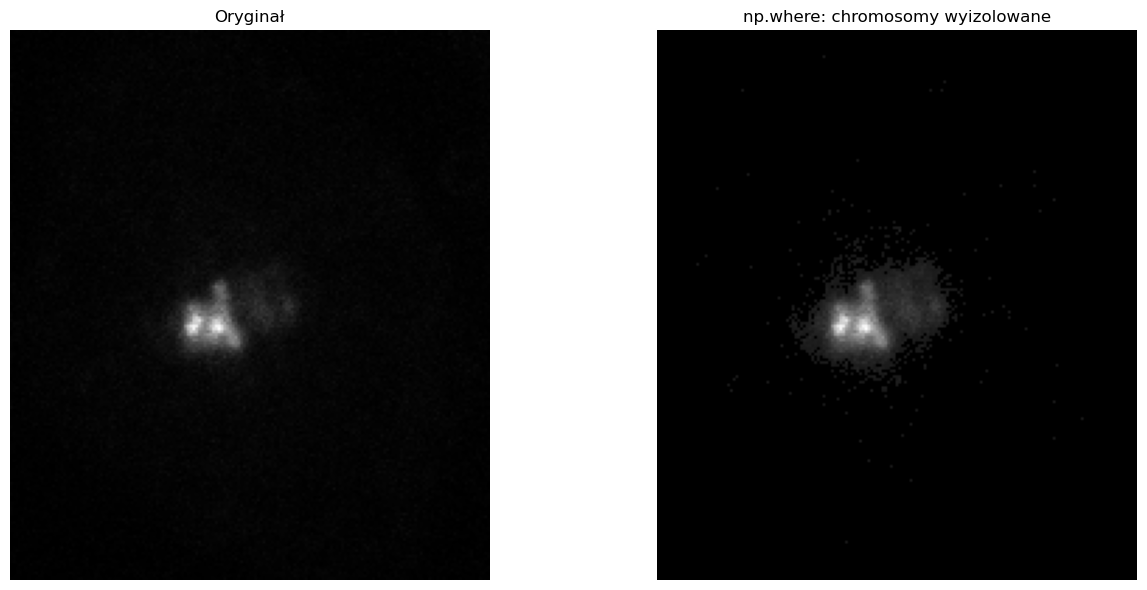

In [48]:
frame = data[25, 2, 0, :, :]

# Boolean indexing — płaski wektor wartości, nie obraz:
bright_values = frame[frame > 3000]
print(f"Boolean indexing → shape: {bright_values.shape}")  # (N,) — 1D

# np.where — obraz z wyzerowanym tłem:
segmented = np.where(frame > 3000, frame, 0)
print(f"np.where → shape: {segmented.shape}")  # (196, 171) — 2D, jak oryginał

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(frame, cmap="gray")
axes[0].set_title("Oryginał")
axes[0].axis("off")

axes[1].imshow(segmented, cmap="gray")
axes[1].set_title("np.where: chromosomy wyizolowane")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### 5.3.5 Boolean indexing po jednej osi

Jest jeszcze jeden wzorzec, który łączy boolean indexing z zachowaniem struktury. Maska 1D może selekcjonować wzdłuż jednej osi:


In [49]:
# Prosty przykład: macierz 4×3 (studenci × egzaminy)
grades = np.array(
    [
        [4, 3, 5],
        [3, 4, 4],
        [5, 5, 4],
        [5, 3, 5],
        [2, 3, 3],
    ]
)

means = grades.mean(axis=1)
means

array([4.        , 3.66666667, 4.66666667, 4.33333333, 2.66666667])

In [50]:
good_mask = means > 4.0
good_mask

array([False, False,  True,  True, False])

In [51]:
# Oceny studentów, którzy mają średnią powyżej 4.0
grades[good_mask]

array([[5, 5, 4],
       [5, 3, 5]])

Kiedy maska ma tyle elementów co długość jednej osi i nie pasuje do całej tablicy — NumPy stosuje ją wzdłuż tej osi, zachowując resztę wymiarów. To bardzo przydatny wzorzec przy filtrowaniu danych.

Zastosowanie na mitozie — **automatyczna selekcja klatek aktywnego podziału**. Na wykładzie 4 widzieliśmy, że średnia jasność klatek monotonicznie spada przez photobleaching. Ale jeśli zamiast surowej jasności zmierzymy **kontrast** (jaką frakcję pikseli stanowią te naprawdę jasne), photobleaching może ulec złagodzeniu:

In [55]:
time_series = data[:, 2, 0, :, :]  # (51, 196, 171)

# # Frakcja pikseli jaśniejszych niż 1.5× średnia danej klatki
# bright_fraction = np.array(
#     [(frame > 1.5 * frame.mean()).mean() for frame in time_series]
# )

In [56]:
frame_means = time_series.mean(axis=(1, 2), keepdims=True)
bright_fraction = (time_series > 1.5 * frame_means).mean(axis=(1, 2))

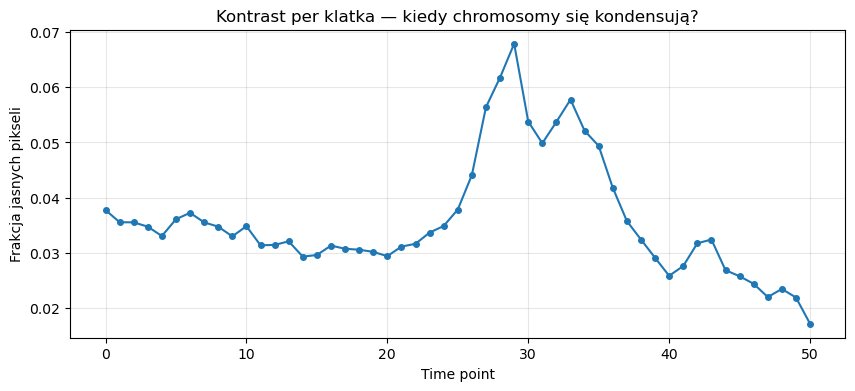

In [57]:
plt.figure(figsize=(10, 4))
plt.plot(bright_fraction, "o-", markersize=4)
plt.xlabel("Time point")
plt.ylabel("Frakcja jasnych pikseli")
plt.title("Kontrast per klatka — kiedy chromosomy się kondensują?")
plt.grid(True, alpha=0.3)
plt.show()

Profil wygląda zupełnie inaczej niż monotoniczny spadek średniej intensywności z wykładu 4. Teraz możemy automatycznie wybrać klatki aktywnego podziału:


In [ ]:
active_mask = bright_fraction > 0.04
print(f"Klatek z aktywną mitozą: {active_mask.sum()} z {len(bright_fraction)}")

# Boolean mask po osi 0 — reszta wymiarów nietknięta
active_frames = time_series[active_mask]
print(f"Shape wybranych klatek: {active_frames.shape}")

In [ ]:
# Montaż wybranych klatek
active_indices = np.where(active_mask)[0]

fig, axes = plt.subplots(1, len(active_indices), figsize=(2.5 * len(active_indices), 3))
for i, t in enumerate(active_indices):
    axes[i].imshow(
        time_series[t],
        cmap="gray",
        vmin=time_series.min(),
        vmax=np.percentile(time_series, 99),
    )
    axes[i].set_title(f"t={t}")
    axes[i].axis("off")
plt.suptitle("Automatycznie wykryte okno aktywnej mitozy", fontsize=13)
plt.tight_layout()
plt.show()

## 5.4 Broadcasting — arytmetyka tablic o różnych kształtach

Do tej pory operowaliśmy na tablicach tego samego kształtu (np. `frame > 3000` — porównanie tablicy ze skalarem to najprostszy przypadek) albo agregowaliśmy tablicę do mniejszego kształtu. Ale co jeśli chcemy **wykonać operację arytmetyczną między tablicami o różnych wymiarach**?


### 5.4.1 Skalar — najłatwiejszy przypadek

Operacje ze skalarem działają intuicyjnie:


In [ ]:
arr = np.array([[1, 2, 3], [4, 5, 6]])
arr * 10

NumPy traktuje skalar tak, jakby miał ten sam kształt co tablica — „rozciąga" go do (2, 3). To jest broadcasting w najprostszej formie.


### 5.4.2 Wektor + macierz

Ciekawiej robi się, gdy oba operandy mają różne niezerowe wymiary:


In [ ]:
# Macierz 3×4: trzy próbki, cztery geny
expression = np.array(
    [
        [100, 200, 50, 300],  # próbka 0
        [20, 180, 60, 280],   # próbka 1
        [90, 220, 40, 320],   # próbka 2
    ]
)

# Średnia per gen — wektor o shape (4,)
gene_means = expression.mean(axis=0)
gene_means

In [ ]:
# Odejmujemy średnią każdego genu od wszystkich próbek
centered = expression - gene_means
centered

Macierz `(3, 4)` minus wektor `(4,)` — NumPy „rozciąga" wektor wzdłuż osi 0, tworząc wirtualną macierz 3×4 ze skopiowanymi wierszami. Operacja jest wykonywana element po elemencie.

Ale co jeśli chcemy odjąć średnią każdej **próbki** (wzdłuż osi 1)?


In [ ]:
# Średnia per próbka — wektor o shape (3,)
sample_means = expression.mean(axis=1)
sample_means

In [ ]:
# To NIE zadziała:
# centered_samples = expression - sample_means  # Error!

Shape `(3, 4)` i `(3,)` — w przypadku niezgodności kształtów NumPy zawsze próbuje dodawać nowe wymiary od lewej strony. W tym przypadku dostajemy `(3, 4)` i `(1, 3)`, które nie są kompatybilne ze względu na różne rozmiary na osi 1. 

Aby temu zaradzić, musimy jawnie dodać wymiar do wektora, mówiąc „ten wektor to kolumna, nie wiersz". Operacja ta odpowiada zanurzeniu wektora w przestrzeni wyżej wymiarowej, z dodatkowym wymaganiem na co położenia na odpowiedniej osi. 

In [ ]:
# Ręcznie dodajemy wymiar: (3,) → (3, 1)
sample_means_col = sample_means[:, np.newaxis]
sample_means_col.shape

In [ ]:
centered_samples = expression - sample_means_col  # (3, 4) - (3, 1) → (3, 4)
centered_samples

### 5.4.3 Reguły broadcastingu

1. Jeśli dwie tablice różnią się wymiarem, to kształt tej o mniejszym wymiarze jest uzupełniany od lewej jedynkami.
2. Jeśli rozmiary na danej osi nie są w obu tablicach równe, to ten który jest równy jeden, jest rozszerzany do większego rozmiaru.
3. Jeśli rozmiary na danej osi nie są w obu tablicach równe i żaden z nich nie jest równy jeden, to broadcasting nie może zostać wykonany. Wtedy rzucany jest wyjątek.


#### Zadanie

Na których kształtach da się wykonać broadcasting?

1. `(1, 2)` i `(3, 4, 2)`
1. `(1, 2)` i `(3, 2, 4)`
1. `(5, 3, 8)` i `(5, 4, 8)`
1. `(5, 3, 8)` i `(5, 8)`
1. `(5, 3, 8)` i `(3, 8)`
1. `(5, 3, 8)` i `(5, 3)`


### 5.4.4 `keepdims` — most do broadcastingu

Wiemy, że `mean(axis=...)` eliminuje wymiar. Ale jest opcja, żeby tego nie robił:


In [ ]:
arr = np.array([[1, 2, 3], [4, 5, 6]])
arr

In [ ]:
arr.mean(axis=1)

In [ ]:
arr.mean(axis=1, keepdims=True)

`keepdims=True` zachowuje wymiar, ale z rozmiarem 1. Dzięki temu wynik jest od razu gotowy do broadcastingu:


In [ ]:
# Z-score per wiersz — z keepdims:
means_k = arr.mean(axis=1, keepdims=True)
stds_k = arr.std(axis=1, keepdims=True)

zscore = (arr - means_k) / stds_k
zscore

Obie wersje dają ten sam wynik. `keepdims` jest wygodniejszy, bo nie trzeba pamiętać o `np.newaxis`.


### 5.4.5 Korekcja photobleachingu

Na wykładzie 4 widzieliśmy, że średnia intensywność klatek monotonicznie spada. Wykonamy korektę tego efektu.

Pomysł: podzielić każdą klatkę (196×171 pikseli) przez jej średnią intensywność, a potem przemnożyć przez globalną średnią (żeby zachować sensowne wartości liczbowe).


In [ ]:
time_series = data[:, 2, 0, :, :]  # (51, 196, 171)

# Średnia per klatka: shape (51,)
intensity = time_series.mean(axis=(1, 2))

# Problem broadcastingu:
# time_series.shape = (51, 196, 171)
# intensity.shape   = (51,)
# Od prawej: 171 vs 51 → BŁĄD

# Rozwiązanie: (51,) → (51, 1, 1)
intensity_3d = intensity[:, np.newaxis, np.newaxis]
intensity_3d.shape

In [ ]:
# Teraz broadcasting działa: (51, 196, 171) / (51, 1, 1) → (51, 196, 171)
global_mean = time_series.mean()
corrected = time_series / intensity_3d * global_mean
corrected.shape

Sprawdźmy, czy korekta zadziałała:


In [ ]:
corrected_intensity = corrected.mean(axis=(1, 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(intensity, "o-", markersize=3)
axes[0].set_title("Przed korektą — photobleaching")
axes[0].set_xlabel("Time point")
axes[0].set_ylabel("Średnia intensywność")
axes[0].grid(True, alpha=0.3)

axes[1].plot(corrected_intensity, "o-", markersize=3, color="green")
axes[1].set_title("Po korekcie — profil wyrównany")
axes[1].set_xlabel("Time point")
axes[1].set_ylabel("Średnia intensywność")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

Lewy wykres to monotoniczny spadek z wykładu 4. Prawy jest płaski — dzielenie przez średnią klatki i mnożenie przez stałą daje po uśrednieniu tę samą wartość dla każdej klatki. To prosta korekcja (zakłada równomierny bleaching), ale w praktyce wystarczająca jako pierwszy krok.

Profil się wyprostował, rezultat możemy zobaczyć na animacji surowych i skorygowanych danych:


In [ ]:
import plotly.express as px

fig = px.imshow(
    time_series,
    animation_frame=0,
    color_continuous_scale="gray",
    labels={"animation_frame": "Time point"},
    title="Time-lapse przed korekcją photobleachingu",
)
fig.update_layout(
    coloraxis=dict(cmin=time_series.min(), cmax=np.percentile(time_series, 99))
)
fig.show()

In [ ]:
import plotly.express as px

fig = px.imshow(
    corrected,
    animation_frame=0,
    color_continuous_scale="gray",
    labels={"animation_frame": "Time point"},
    title="Time-lapse po korekcji photobleachingu",
)
fig.update_layout(
    coloraxis=dict(cmin=corrected.min(), cmax=np.percentile(corrected, 99))
)
fig.show()

Porównajmy z animacją surowych danych z wykładu 4: tam późne klatki były wyraźnie ciemniejsze od wczesnych. Tutaj jasność tła jest stabilna na przestrzeni całego nagrania — widać same zmiany biologiczne, bez artefaktu.


### 5.4.6 Pseudokolorowy obraz — nakładanie kanałów

Na wykładzie 4 widzieliśmy oba kanały osobno — chromosomy i wrzeciono na oddzielnych obrazach. W mikroskopii standardem jest **nakładanie kanałów jako pseudo-RGB**: jeden kanał → zielony, drugi → czerwony. Tam, gdzie obie struktury się pokrywają, widzimy żółty.

Do tego potrzebujemy złożyć macierz (Y, X, 3) z trzech warstw — a to wymaga normalizacji obu kanałów do zakresu 0–1 (broadcasting!) i złożenia ich w tensor RGB:


In [ ]:
# Oba kanały, t=25, Z=2
ch0 = data[25, 2, 0, :, :].astype(float)  # chromosomy
ch1 = data[25, 2, 1, :, :].astype(float)  # wrzeciono

# Normalizacja do [0, 1] — broadcasting ze skalarem
ch0_norm = (ch0 - ch0.min()) / (ch0.max() - ch0.min())
ch1_norm = (ch1 - ch1.min()) / (ch1.max() - ch1.min())

# Wzmocnienie kontrastu: percentylowe obcięcie
p99_ch0 = np.percentile(ch0_norm, 99)
p99_ch1 = np.percentile(ch1_norm, 99)
ch0_norm = np.clip(ch0_norm / p99_ch0, 0, 1)
ch1_norm = np.clip(ch1_norm / p99_ch1, 0, 1)

# Składamy pseudo-RGB: R = wrzeciono, G = chromosomy, B = zera
zeros = np.zeros_like(ch0_norm)
rgb = np.stack([ch1_norm, ch0_norm, zeros], axis=2)  # (196, 171, 3)
rgb.shape

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].imshow(ch0_norm, cmap="Greens")
axes[0].set_title("Kanał 0: chromosomy (zielony)")
axes[0].axis("off")

axes[1].imshow(ch1_norm, cmap="Reds")
axes[1].set_title("Kanał 1: wrzeciono (czerwony)")
axes[1].axis("off")

axes[2].imshow(rgb)
axes[2].set_title("Overlay — kolokalizacja = żółty")
axes[2].axis("off")

plt.tight_layout()
plt.show()

Na nałożonym obrazie widać przestrzenne relacje obu struktur: chromosomy (zielone punkty) otoczone wrzecionem (czerwona struktura wrzecionowata). Regiony żółte — tam, gdzie obie struktury się pokrywają — to miejsca, gdzie mikrotubule wrzeciona przyczepiają się do chromosomów.

## 5.5 Kolorowy film mitozy — podsumowanie w jednym obrazie

Umiemy już tworzyć pseudo-RGB overlay dla jednej klatki (sekcja 5.4.6) i korygować photobleaching (sekcja 5.4.5). Połączmy te techniki: zbudujemy **kolorowy film mitozy**, w którym oba kanały są nałożone na siebie w każdej klatce. To podsumowanie całego wykładu — indeksowanie, normalizacja (broadcasting), `np.stack`, `np.clip`, Plotly.


In [ ]:
rgb_movie = []
for t in range(51):
    ch0 = data[t, 2, 0, :, :].astype(float)
    ch1 = data[t, 2, 1, :, :].astype(float)

    # Normalizacja + wzmocnienie kontrastu (broadcasting ze skalarem)
    ch0_n = np.clip((ch0 - ch0.min()) / (np.percentile(ch0, 99) - ch0.min()), 0, 1)
    ch1_n = np.clip((ch1 - ch1.min()) / (np.percentile(ch1, 99) - ch1.min()), 0, 1)

    # R = wrzeciono, G = chromosomy, B = zera
    rgb_movie.append(np.stack([ch1_n, ch0_n, np.zeros_like(ch0_n)], axis=2))

rgb_movie = np.array(rgb_movie)  # (51, 196, 171, 3)
rgb_movie.shape

In [ ]:
fig = px.imshow(
    rgb_movie,
    animation_frame=0,
    labels={"animation_frame": "Time point"},
    title="Mitoza — chromosomy (zielony) + wrzeciono (czerwony)",
)
fig.show()

To jest pełna historia podziału komórkowego w kolorze:

**Klatki 0–20:** Chromosomy (zielone/żółte punkty) są skupione w centrum komórki. Wrzeciono (czerwone łuki) rozciąga się między dwoma biegunami. Żółty kolor w centrum oznacza kolokalizację — mikrotubule wrzeciona przyczepiają się do chromosomów.

**Klatki ~25–35:** Chromosomy rozjeżdżają się do biegunów — żółty kolor „podwaja się", widać dwie grupy wędrujące w przeciwnych kierunkach. To anafaza, kluczowy moment mitozy.

**Klatki ~35–50:** Chromosomy dekondensują się przy biegunach (zielony sygnał słabnie). W centrum komórki utrzymuje się żółty sygnał — to najprawdopodobniej midzone, gęsta wiązka mikrotubul, która formuje się między rozdzielonymi jądrami. Sygnał chromosomowy (kanał 0) w tym regionie może wynikać z przebicia spektralnego między kanałami fluorescencyjnymi — rozstrzygnięcie wymagałoby dostępu do protokołu barwienia.

Na jednym filmie widzimy zarówno biologię (dynamikę podziału), jak i artefakty (możliwe przebicie spektralne). To typowa sytuacja w analizie danych mikroskopowych — i dobry nawyk, żeby zawsze pytać „czy to sygnał, czy artefakt?".


## 5.6 Podsumowanie


### Co umiemy po wykładzie 5

**Indeksowanie — trzy mechanizmy:**

✅ Basic slicing: `arr[1:3, 0:2]` — zakresy, zwraca widok  
✅ Fancy indexing: `arr[[0, 3, 6]]` — lista pozycji, zwraca kopię  
✅ Boolean indexing: `arr[arr > 5]` — maska logiczna, zwraca 1D  
✅ `np.where(condition, x, y)` — zamiennik zachowujący kształt  
✅ Maska 1D po jednej osi — filtrowanie wierszy/klatek

**Osie i agregacje:**

✅ Oś = kierunek indeksu; `axis=N` eliminuje wymiar N  
✅ `keepdims=True` — zachowuje wymiar jako 1 (przydatne do broadcastingu)  
✅ Agregacja po wielu osiach: `mean(axis=(1, 2))`

**Broadcasting:**

✅ Skalar, wektor, macierz — reguły dopasowywania kształtów  
✅ `np.newaxis` i `keepdims` — przygotowanie do broadcastingu  
✅ Zastosowanie: normalizacja, z-score, korekcja artefaktów

**Nowe wyniki na danych mitozy:**

✅ Profil Z — obie struktury najjaśniejsze w warstwie 2  
✅ Krzywa kontrastu — automatyczna detekcja okna aktywnej mitozy  
✅ Korekcja photobleachingu — broadcasting w praktyce  
✅ Pseudokolorowy overlay kanałów — kolokalizacja chromosomów i wrzeciona  
✅ Kolorowy film mitozy — pełna dynamika podziału w jednej animacji


### Zapowiedź wykładu 6

Przez dwa wykłady pracowaliśmy z danymi, które miały naturalną strukturę przestrzenną — piksele ułożone w obraz, kanały, warstwy Z. Wymiary miały fizyczną interpretację (pozycja, czas, głębokość).

Na następnym wykładzie zmierzymy się z danymi, w których wymiary **nie mają** tak oczywistej interpretacji — 39 zmiennych klinicznych, setki genów, tysiące metabolitów. Jak zobaczyć wzorce w przestrzeni o 39 wymiarach? Jak zredukować ją do 2–3 wymiarów, które da się zwizualizować? To pytanie, na które odpowiada **redukcja wymiarowości**: PCA, t-SNE, UMAP.


### Źródła i dalsza lektura

**Broadcasting:**
* NumPy broadcasting docs: https://numpy.org/doc/stable/user/basics.broadcasting.html
* Visual guide: https://jakevdp.github.io/PythonDataScienceHandbook/02.05-computation-on-arrays-broadcasting.html

**Indeksowanie:**
* NumPy indexing docs: https://numpy.org/doc/stable/user/basics.indexing.html

**Książki:**
* Jake VanderPlas, "Python Data Science Handbook" — rozdziały o NumPy
* Robert Laganière, "OpenCV 4 Computer Vision Application Programming Cookbook" — jeśli zainteresowała Was praca z obrazami


### Zadania do samodzielnej pracy

1. **Z-score normalizacja per klatka:**
   Korekcja photobleachingu z sekcji 5.4.5 dzieliła przez średnią. Spróbuj bardziej zaawansowanej normalizacji: dla każdej klatki oblicz z-score (odejmij średnią, podziel przez std). Użyj `keepdims=True`. Jak zmieni się profil temporalny?

2. **Profil Z w czasie:**
   W sekcji 5.2.4 policzyliśmy profil Z dla jednego momentu. Oblicz go dla *wszystkich* 51 klatek — wynik to macierz (51, 5). Wyświetl jako heatmapę (`plt.imshow` z `aspect='auto'`). Czy warstwa najjaśniejsza zmienia się w czasie?

3. **Korelacja kanałów w czasie:**
   Dla jednego piksela (np. `[100, 85]`) wyciągnij serię czasową z obu kanałów. Zrób scatter plot (kanał 0 vs kanał 1, 51 punktów). Czy piksele, w których jest dużo chromosomów, mają też dużo wrzeciona? Powtórz dla piksela z tła. Jaka jest różnica?

4. **Kolorowy film z max projection:**
   W sekcji 5.5 budowaliśmy RGB film z jednej warstwy Z. Zmodyfikuj kod tak, żeby najpierw zrobić max projection po Z (osobno per kanał), a potem składać overlay. Wynik: animacja, w której widzimy pełną strukturę 3D spłaszczoną do 2D, w kolorze. Czy widać więcej szczegółów niż na pojedynczej warstwie?

5. **Detekcja ruchu per piksel:**
   Oblicz różnicę między kolejnymi klatkami: `diff = np.abs(np.diff(time_series, axis=0))`. Następnie zsumuj `|diff|` po osi czasu: `total_movement = diff.sum(axis=0)`. Wynik to obraz 196×171, który pokazuje *gdzie* w komórce było najwięcej ruchu. Porównaj z mapą std z wykładu 4 — czy pokazują to samo?